Description: Learn to work with data efficiently using industry-standard libraries.

Libraries: NumPy, Pandas, Matplotlib, Seaborn

Topics to Cover:
- NumPy arrays and vectorized operations
- Pandas DataFrames, indexing, filtering
- Data cleaning (handling missing values, duplicates)
- Exploratory Data Analysis (EDA)
- Creating effective visualizations

Hands-on Projects:
- Sales Data Analysis: Load a sales dataset, clean it, perform EDA, and create dashboards
- COVID-19 Data Visualization: Download real-world data and create time-series plots
- Customer Segmentation EDA: Explore customer data and identify patterns

## Sales EDA

In [131]:
import shutil

shutil.copy2("dirty_cafe_sales.csv", "01_dirty_cafe_sales.csv")

'01_dirty_cafe_sales.csv'

In [132]:
import pandas as pd

df = pd.read_csv('01_dirty_cafe_sales.csv')

df

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2,2.0,4.0,NaN,UNKNOWN,2023-08-30
9996,TXN_9659401,NaN,3,NaN,3.0,Digital Wallet,NaN,2023-06-02
9997,TXN_5255387,Coffee,4,2.0,8.0,Digital Wallet,NaN,2023-03-02
9998,TXN_7695629,Cookie,3,NaN,3.0,Digital Wallet,NaN,2023-12-02


In [133]:
df["Quantity"] = pd.to_numeric(df["Quantity"], errors="coerce")
df["Price Per Unit"] = pd.to_numeric(df["Price Per Unit"], errors="coerce")
df["Total Spent"] = pd.to_numeric(df["Quantity"], errors="coerce")
df["Transaction Date"] = pd.to_datetime(df["Transaction Date"], errors="coerce")

for col in df:
    df[col] = df[col].replace(["UNKNOWN", "ERROR"], value=None)

df.dropna(inplace=True) #remove NaN
df

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2.0,2.0,2.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4.0,3.0,4.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4.0,1.0,4.0,Credit Card,In-store,2023-07-19
4,TXN_3160411,Coffee,2.0,2.0,2.0,Digital Wallet,In-store,2023-06-11
10,TXN_2548360,Salad,5.0,5.0,5.0,Cash,Takeaway,2023-11-07
...,...,...,...,...,...,...,...,...
9977,TXN_5548914,Juice,2.0,3.0,2.0,Digital Wallet,In-store,2023-11-04
9979,TXN_9933628,Smoothie,5.0,4.0,5.0,Cash,In-store,2023-07-20
9986,TXN_2858441,Sandwich,2.0,4.0,2.0,Credit Card,In-store,2023-12-14
9991,TXN_3897619,Sandwich,3.0,4.0,3.0,Cash,Takeaway,2023-02-24


#### Dashboard

In [134]:
print("Total Sales: ", df["Total Spent"].sum())
print("Total Items Sold: ", df["Quantity"].sum())
print("Total Quantity Sold: ", df["Quantity"].sum())
print("Average Transaction Value: ", round(float((df["Total Spent"].mean())), 2))

Total Sales:  9790.0
Total Items Sold:  9790.0
Total Quantity Sold:  9790.0
Average Transaction Value:  3.03


C:\Users\Shail Patel\AppData\Local\Temp\ipykernel_29584\656881498.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_sales = df.groupby("Month")["Total Spent"].sum()


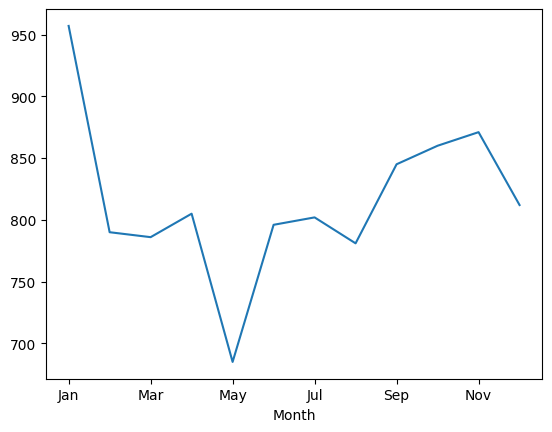

In [135]:
import matplotlib.pyplot as plt

months = ["Jan","Feb","Mar","Apr","May","Jun",
          "Jul","Aug","Sep","Oct","Nov","Dec"]

df["Month"] = df["Transaction Date"].dt.strftime("%b")

df["Month"] = pd.Categorical(
    df["Month"],
    categories=months,
    ordered=True
)

monthly_sales = df.groupby("Month")["Total Spent"].sum()

monthly_sales.plot()

plt.show()

<Axes: ylabel='Item'>

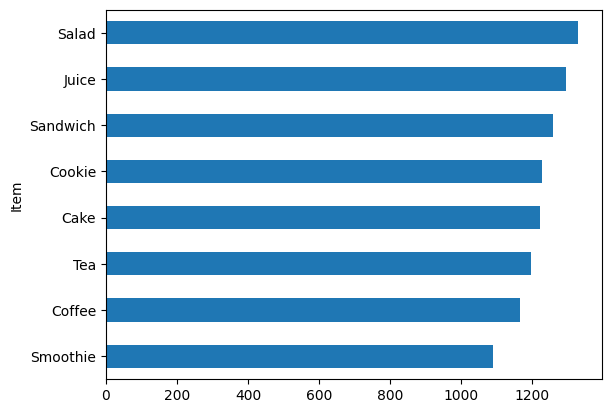

In [136]:
df.groupby("Item")["Quantity"].sum().sort_values().plot(kind="barh")

<Axes: ylabel='count'>

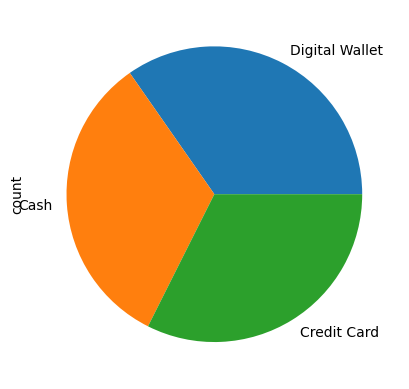

In [137]:
df["Payment Method"].value_counts().plot(kind="pie")

## Covid-19 Dataset

In [4]:
import pandas as pd

df = pd.read_csv('02_covid_19_india.csv')
display(df)

,Sno,Date,Time,State/UnionTerritory,ConfirmedIndianNational,ConfirmedForeignNational,Cured,Deaths,Confirmed
0,1,2020-01-30,6:00 PM,Kerala,1,0,0,0,1
1,2,2020-01-31,6:00 PM,Kerala,1,0,0,0,1
2,3,2020-02-01,6:00 PM,Kerala,2,0,0,0,2
3,4,2020-02-02,6:00 PM,Kerala,3,0,0,0,3
4,5,2020-02-03,6:00 PM,Kerala,3,0,0,0,3
...,...,...,...,...,...,...,...,...,...
18105,18106,2021-08-11,8:00 AM,Telangana,-,-,638410,3831,650353
18106,18107,2021-08-11,8:00 AM,Tripura,-,-,77811,773,80660
18107,18108,2021-08-11,8:00 AM,Uttarakhand,-,-,334650,7368,342462
18108,18109,2021-08-11,8:00 AM,Uttar Pradesh,-,-,1685492,22775,1708812


In [5]:
df["Date"] = pd.to_datetime(df["Date"])

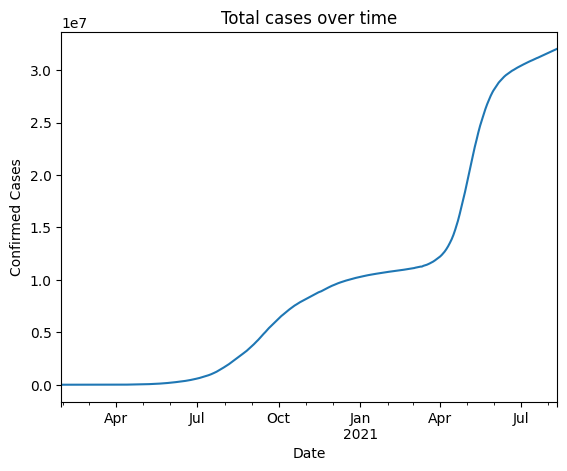

In [11]:
import matplotlib.pyplot as plt

plt.title("Total cases over time")
plt.ylabel("Confirmed Cases")
daily_cases = df.groupby("Date")["Confirmed"].sum()
daily_cases.plot()
plt.show()

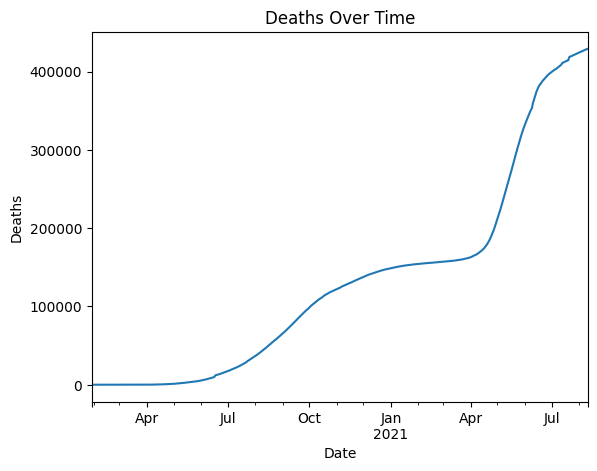

In [13]:
plt.title("Deaths Over Time")

plt.ylabel("Deaths")
daily_deaths = df.groupby("Date")["Deaths"].sum()
daily_deaths.plot()
plt.show()